In [1]:
import os
from dotenv import load_dotenv
from langchain_anthropic import ChatAnthropic
from langchain_tavily import TavilySearch
load_dotenv()

/Users/akashdeepsangwan/Desktop/Code/GenAI/AgenticAI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
api_key = os.getenv("claudeAPI")

llm = ChatAnthropic(
    model = "claude-haiku-4-5-20251001",
    api_key= api_key
)

In [3]:
tavily_tool = TavilySearch(
       tavily_api_key=os.getenv("tavilyAPI"),  
       max_results=5
   )

In [4]:
from typing import Annotated, List
from langchain_tavily import TavilySearch
from langchain_core.tools import StructuredTool
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.tools import WikipediaQueryRun
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import TextLoader



from langgraph.graph import StateGraph, START, END

In [5]:
Embeddings = HuggingFaceEmbeddings(
    model_name  = "sentence-transformers/all-MiniLM-L6-v2"
)

In [6]:
def make_retriever_tool_from_text(file, name, desc) :
    docs = TextLoader(file, encoding= "utf-8").load()
    chunks = RecursiveCharacterTextSplitter(chunk_size = 500, chunk_overlap = 50).split_documents(docs)
    vs  = FAISS.from_documents(chunks, Embeddings)
    retriever = vs.as_retriever()

    
    def tool_func(query : str) -> str :
        print(f"Using tool : {name}")
        result = retriever.invoke(query)
        return "\n\n".join(doc.page_content for doc in result)

    return StructuredTool.from_function( name = name, description= desc, func = tool_func)



internal_tool_1 = make_retriever_tool_from_text("/Users/akashdeepsangwan/Desktop/Code/GenAI/AgenticAI/MultiAgentRAG/research_notes.txt",
                                                "retriever_tool", "retrieves the document"
                                            )
internal_tool_1


StructuredTool(name='retriever_tool', description='retrieves the document', args_schema=<class 'langchain_core.utils.pydantic.retriever_tool'>, func=<function make_retriever_tool_from_text.<locals>.tool_func at 0x124a7a5c0>)

### Command
- In langraph it is used for dynamic routing and controlling which node runs next.
- It replaces fixed edges with runtime decisions

-- it let next node to run or (END)

In [7]:
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.prebuilt import create_react_agent
from langgraph.graph import MessagesState, END
from langgraph.types import Command

def get_next_node(last_message : BaseMessage, goto : str) :
    if "FINAL ANSWER" in last_message.content  :
        # Any agent decided the work is done
        return END
    return goto


In [8]:
def make_system_prompt(suffix : str) -> str :
    return(
        "You are a helpful AI assistant, collaborating with other assistants."
        "Use the provided tools to progress towards answering the question"
        "If you are unable to fully answer, that's OK, use another assistant with different tools"
        "Will help where you left off. Execute where you can to make progress."
        "If you or nay of the other assitants have the final answer or deliverable"
        "prefix you response with FINAL ANSWER so the team knows to stop"
        f"\n{suffix}"
    )

/var/folders/58/7rk_l2gn3lv73f_nlj98yjgc0000gn/T/ipykernel_4136/1668823114.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent = create_react_agent(


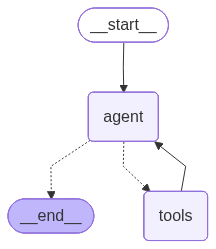

In [9]:
## Research Agent and Node
research_agent = create_react_agent(
    llm,
    tools = [internal_tool_1, tavily_tool],
    prompt = make_system_prompt("You can only do research. Use the tool that you are binded with, you can use both of them")
)

research_agent

In [10]:
from typing import Literal
## Research Node
def research_node(state : MessagesState) -> Command[Literal['blog_generator', END]] :
    result = research_agent.invoke(state)
    goto  = get_next_node(result["messages"][-1], "blog_generator")
    
    result['messages'][-1] = HumanMessage(
        
        content = result["messages"][-1].content, name = "researcher"
    )

    return Command(
        update = {
            "messages" : result['messages']
        }, goto=goto,
    )
    

In [11]:
# Blog write agent
blog_agent = create_react_agent(
    llm, tools = [tavily_tool],
    prompt = make_system_prompt("You can only write a detailed blog. You are working with a researcher colleague.")
)



def blog_node(state : MessagesState) -> Command[Literal['researcher', END]] :
    result = blog_agent.invoke(state)
    goto= get_next_node(result["messages"][-1], "researcher")

    result['messages'][-1] = HumanMessage(
        content = result['messages'][-1].content, name = "blog_generator"
    )
    
    return Command(
        update = {
            "messages" : result["messages"]
        }, 
        goto = goto
    )


/var/folders/58/7rk_l2gn3lv73f_nlj98yjgc0000gn/T/ipykernel_4136/515743835.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  blog_agent = create_react_agent(


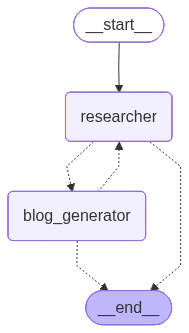

In [12]:
workflow = StateGraph(MessagesState)
workflow.add_node("researcher", research_node)
workflow.add_node("blog_generator", blog_node)

workflow.add_edge(START, "researcher")
graph = workflow.compile()
graph

In [17]:
result = graph.invoke({"messages": "Write a detailed blog on tranformer varient in production deployments"})['messages'][-1].content 

In [18]:
print(result)

Now I have comprehensive information. Let me compile a detailed blog post on transformer variants in production deployments.

---

# FINAL ANSWER

## **Transformer Variants in Production Deployments: A Comprehensive Guide**

### **Introduction**

Transformer models have revolutionized machine learning, powering everything from chatbots to search engines and advanced AI assistants. However, deploying these powerful models in production environments presents unique challenges that differ significantly from research and experimentation. Organizations face critical constraints around latency, memory footprint, cost optimization, and scaling inference—all while maintaining model accuracy and performance.

This comprehensive guide explores the diverse landscape of transformer variants designed specifically for production deployments, examining their architectural innovations, optimization techniques, and real-world applications.

---

### **Part 1: Understanding Production Challenges**

Befo

## SuperVisor 

- It's a multiagent architecture where specialised agents are coordinated by a central supervisor agent. The supervisor agent controls all the communications flow and task delegation, making decisions about which agent to invoke based on the corrent context and task requirements

- I will build a supervisor system with two agents 
- A research and a math expert

- So I can build a supervisor for orchestrating them with the prebuilt langgraph supervisor

In [ ]:
internal_tool_1 # retriever tool

StructuredTool(name='retriever_tool', description='retrieves the document', args_schema=<class 'langchain_core.utils.pydantic.retriever_tool'>, func=<function make_retriever_tool_from_text.<locals>.tool_func at 0x124a7a5c0>)

In [20]:
tavily_tool

TavilySearch(max_results=5, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None))

In [22]:
from langchain_tavily import TavilySearch
web_search = TavilySearch(
    tavily_api_key = os.getenv("tavilyAPI"),
    max_result = 3)
web_search

TavilySearch(api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None))

/var/folders/58/7rk_l2gn3lv73f_nlj98yjgc0000gn/T/ipykernel_4136/2457867047.py:4: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent = create_react_agent(


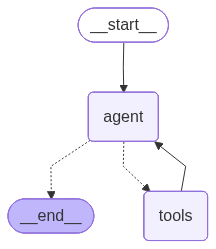

In [ ]:
from langgraph.prebuilt import create_react_agent

research_agent = create_react_agent(
    model = llm,
    tools = [web_search, internal_tool_1],
    prompt = (
        "You are a research agent. \n\n"
        "Instructions: \n"
        "Assist only with research related task, respind to the supervisor directly \n"
        "Respond only with the results of your work do not include any other text"
    ),
    name = "research agent"
)

research_agent

/var/folders/58/7rk_l2gn3lv73f_nlj98yjgc0000gn/T/ipykernel_4136/2243745222.py:17: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  math_agent = create_react_agent(


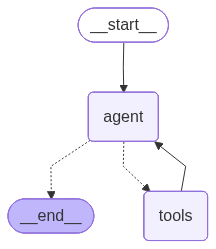

In [28]:
# Functions for the maths agent

def add(a : float , b : float) :
    """ Add two numbers  """
    return a+b

def multiply(a : float, b : float) :
    """ Multiply two numbers """
    return a*b

def divide(a : float, b : float) :
    """ Divide two numbers """
    return a/b



math_agent = create_react_agent(
    model = llm,
    tools = [add,multiply, divide],
    prompt = (
        "You are a math agent. \n\n"
        "Instructions :  \n"
        "- Assist only with math related task \n"
        "After you are done with tasks, respond to the supervisor directly\n"
        "- Respond only with the results of your work, don't include any other text."
    ),
    name = "math_agent"

)

math_agent

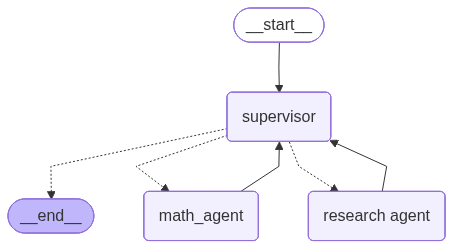

In [36]:
# making the supervisor agent

from langgraph_supervisor import create_supervisor

supervisor = create_supervisor(
    model = llm,
    agents = [research_agent, math_agent],
    prompt = (
    "You are a supervisor managing two agents : \n"
    "- a research_agent. Assign research related tasks to this agent \n"
    "- a math agent. Assign math related task to this agent \n"
    "Assign work to one agent at a time, do not call agent in parallel. \n"
    "Don't do any work yourself"
    ),
    add_handoff_back_messages=  True,
    output_mode = "full_history"
).compile()

supervisor

In [37]:
response  = supervisor.invoke({"messages" : "list all the transformes varients in the production deployments from the retriever and then tell me what is 5 plus 10"})


Using tool : retriever_tool


In [39]:
response

{'messages': [HumanMessage(content='list all the transformes varients in the production deployments from the retriever and then tell me what is 5 plus 10', additional_kwargs={}, response_metadata={}, id='7d76b698-b90b-4fde-882b-3de5375386e3'),
  AIMessage(content=[{'text': "I'll help you with both tasks. Let me start by asking the research agent to find information about the transformer variants in production deployments from the retriever.", 'type': 'text'}, {'id': 'toolu_01CWDjgmjbkciPdaHHpQzGwY', 'input': {'task': 'List all the transformer variants in the production deployments from the retriever'}, 'name': 'transfer_to_research_agent', 'type': 'tool_use', 'caller': {'type': 'direct'}}], additional_kwargs={}, response_metadata={'id': 'msg_014vWna69fuqgcWvD2DphE5U', 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cach

In [43]:
print(response["messages"][-1].content)


## Summary:

**Transformer Variants in Production Deployments:**
1. **EfficientFormer** - Raspberry Pi 4 deployment
2. **Longformer** - Customer support logs (8K tokens)
3. **Reformer** - LSH attention mechanism
4. **TinyBERT** - Support ticket classification
5. **LLaMA2** - RAG-integrated chatbot
6. **FlashAttention2** - Integrated into LLaMA2

**5 plus 10 = 15**


### Hierarichal Agents

- Single SUPERVISOR route the work between different worker nodes 
- But what if the job for a single worker become too complex ? what is the number of workers becomes too large ?
- For some applications, the system may be more effective if work is distributed hierarchially.
- It can be done by composing different subgraphs and creating a top-level supervisor along with mid-level supervisors 

In [48]:
from typing import Annotated, List
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.tools import tool


In [ ]:
@tool
def scrape_webpages(urls : List[str]) -> str:
    """ Use requests and bs4 to scrape the provided web pages for detailed information """
    loader = WebBaseLoader(urls)
    docs = loader.load()

    return "\n\n".join(
        [f'<Document name = "{doc.metadata.get("title", "")}">\n   {doc.page_content}\n </Document>'
        for doc in docs 
        ]
    )

In [86]:
# If we want to generate some kind of notes or task, we need to create a temp directory
from pathlib import Path 
from tempfile import TemporaryDirectory
from typing import Dict, Optional

from langchain_experimental.utilities import PythonREPL # it creates the charts
from typing_extensions import TypedDict

_TEMP_Directory = TemporaryDirectory()
WORKING_DIRECTORY = Path(_TEMP_Directory.name)


@tool
def create_outline(
    points : Annotated[List[str], "List of main points or sections"], 
    file_name : Annotated[str, "File path to save the outline"],    
) -> Annotated[str, "Path of the saved outline file"] :
    """ Create and save the outline """
    with (WORKING_DIRECTORY/file_name).open("w") as file :
        for i, point in enumerate(points) :
            file.write(f"{i+1}. {point}")
    return f"Outlined saved to {file_name}"

@tool 
def write_document(
    content : Annotated[str, "Text content to be written into the document"]
    , file_name  : Annotated[str, "File path to save the document"]
) -> Annotated[str, "Path of the saved document file"] :
    """ Create and save a text document """
    with (WORKING_DIRECTORY/file_name).open("w") as file :
        file.write(content)
    return f"Document saved to {file_name}"


@tool 
def edit_document(
    file_name : Annotated[str, "Path of the document to be edited"],
    inserts : Annotated[Dict[int, str], "Dictionary where key is the line number and value is the text to be inserted at that line"]
) -> Annotated[str, "Path of the edited docucument file"] :
    """ Edit a document by insering text at the specific line number"""

    with (WORKING_DIRECTORY/file_name).open("r") as file :
        lines = file.readlines()

    sorted_inserts = sorted(inserts.items())

    for line_number, text in sorted_inserts :
        if 1<= line_number <= len(lines) +1 :
            lines.insert(line_number-1, text+"\n")
        else :
            return f"Error : Line number {line_number} is out of range" 
    
    with (WORKING_DIRECTORY/file_name).open("w") as file :
        file.writelines(lines)

    return f"Document edited and saved to {file_name}"

    


In [57]:
# PythonREPL()  - USED TO CREATE THE CHART

repl = PythonREPL()

@tool
def python_repl_tool(
    code : Annotated[str, "The python code to execute to generate your chart"]
) : 
    """ Use this to execute python code. If you want to see the output of a value
    You should print it out with print(...). This is visible to the user
    """

    try :
        result = repl.run(code)

    except BaseException as e :
        return f"Failed to execute. Error {repl(e)}"

    return f"sucessfully executed : \n  python\n {code}\n Stdout : {result} "
    

In [59]:
# creating supervisor - we need a state
from typing import List, Optional, Literal
from langchain_core.language_models.chat_models import BaseChatModel


# MessagesState - automatically configues the add_messages reducer and let you add the  new messages -> Basically it store the message without overwriting
# In builde reducer inside the MessageState


from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.types import Command
from langchain_core.messages import HumanMessage, trim_messages

class State(MessagesState) :
    next : str
    

### For the supervisor Node, I will write the generic function

- members  : How many different subnodes 
- 

In [75]:
def make_supervisor_node(llm : BaseChatModel, members : list[str]) -> str :
    options = ["FINISH"] + members

    system_prompt = (
        "You are a supervisor tasked with managing a conversion between the "
        f"following workers : {members}. Given the following user request"
        "respond with the worker to act next. Each worker will perform a task "
        "and respond with their results and status. When finished, repond with FINISH" )

    
    class Router(TypedDict) :
        """Worker to route to next. If no worker needed, route to finish """
        next : Literal[*options]

    
    def supervisor_node(state : State) -> Command :
        """ An LLM based router."""
        messages  = [
            {"role" : "system", "content" : system_prompt},

        ] + state["messages"]
        
        response = llm.with_structured_output(Router).invoke(messages)
        goto = response["next"]
        
        if goto == "Finish" :
            goto = END

        
        return Command(goto = goto , update= {"next" : goto})
    return supervisor_node

### Connection

- First I created a agent using create_react_agent -> it's a ReAct Agent where I binded the tools
- As I want to use this agent inside the graph workflow, I created a function and it will be given as a node inside the graph
- This function take the state and generate the answer using the agent and then sends the result back to supervisor 

In [62]:
from langchain_core.messages import HumanMessage
from langgraph.prebuilt import create_react_agent

search_agent = create_react_agent(llm, tools= [tavily_tool, internal_tool_1])
search_agent

def search_node(state : State) -> Command[Literal["supervisor"]] :
    result = search_agent.invoke(state)

    return Command(
        update = {
            "messages" : [HumanMessage(content = result["messages"][-1].content, name = "search")
            ]
        }, goto= "supervisor"  # once the search node answer the query it will send the response back to it's supervisor
    )

/var/folders/58/7rk_l2gn3lv73f_nlj98yjgc0000gn/T/ipykernel_4136/2624796136.py:4: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  search_agent = create_react_agent(llm, tools= [tavily_tool, internal_tool_1])


### WEB Scrapter Agent

In [65]:
web_scraper_agent = create_react_agent(
    llm, tools = [scrape_webpages]
    )

def web_scraper_node(state : State) -> Command[Literal["supervisor"]] :
    result  = web_scraper_agent.invoke(state)

    return Command(
        update = {"messages" : [HumanMessage(content = result["messages"][-1].content, name = "web_scraper")]}, goto = "supervisor"
    )

/var/folders/58/7rk_l2gn3lv73f_nlj98yjgc0000gn/T/ipykernel_4136/4232462319.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  web_scraper_agent = create_react_agent(


In [76]:
research_supervisor_node = make_supervisor_node(llm, ["search", "web_scraper"])

### Researcher Graph

Figure out why "Supervisor - END" node not get connected

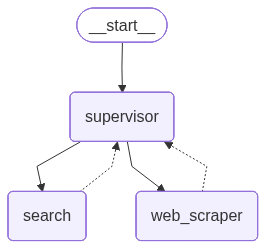

In [ ]:
research_builder = StateGraph(State)
research_builder.add_node("supervisor", research_supervisor_node)
research_builder.add_node("web_scraper", web_scraper_node)
research_builder.add_node("search", search_node)

research_builder.add_edge(START, "supervisor")
research_builder.add_edge("supervisor", "web_scraper")
research_builder.add_edge("supervisor", "search")
research_builder.add_edge("supervisor", END) # not connected

research_graph  = research_builder.compile()
research_graph

### Doc Writer Agent

In [82]:
@tool
def read_document(
    file_name: Annotated[str, "File path to read the document from."],
    start: Annotated[Optional[int], "The start line. Default is 0"] = None,
    end: Annotated[Optional[int], "The end line. Default is None"] = None,
) -> str:
    """Read the specified document."""
    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()
    if start is None:
        start = 0
    return "\n".join(lines[start:end])

- When we return Command(update : {"message" : [], name = ""}) 
- Here we also updating the name of the agents too
- Example : doc_writer_agent
- Inside the it's node function - we change it to "doc_writer"

- The new name of the doc_writer_agent = "doc_writer"
- So while assigning these agent as a tool to a supervisor, we need to use new name "doc_writer"

In [88]:



doc_writer_agent = create_react_agent(llm, tools = [write_document, edit_document, read_document]
, prompt = (
    "You can read, write and edit the document based on the note-takers outlines"
    "Don't ask follow up questions"
))


def doc_writing_node(state : State) -> Command[Literal["supervisor"]] :
    result = doc_writer_agent.invoke(state)
    return Command(
        update = {
            "messages" : [
                HumanMessage(content = result["messages"][-1].content, name = "doc_writer")
            ]
        }, goto = "supervisor"
    )


    
note_taking_agent = create_react_agent(
    llm,
    tools=[create_outline, read_document],
    prompt=(
        "You can read documents and create outlines for the document writer. "
        "Don't ask follow-up questions."
    ),
)


def note_taking_node(state: State) -> Command[Literal["supervisor"]]:
    result = note_taking_agent.invoke(state)
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="note_taker")
            ]
        },
        # We want our workers to ALWAYS "report back" to the supervisor when done
        goto="supervisor",
    )


chart_generating_agent = create_react_agent(
    llm, tools=[read_document, python_repl_tool]
)

# chart generating agent
chart_generating_agent = create_react_agent(llm, tools = [read_document, python_repl_tool])

# Command[Literal ["supervisor"]] - tell it's will go to supervisor after returning it's output
def chart_generating_node(state : State) -> Command[Literal["supervisor"]] :
    result  = chart_generating_agent.invoke(state)
    return Command(
        update = {"messages" : [ HumanMessage(content = result["messages"][-1].content, name = "chart_generator")] } 
        , goto = "supervisor" # report back to supervisor
    )



# To maintain the doc_writing and charts we need a supervisor
doc_writing_supervisor_node = make_supervisor_node(
    llm, ["doc_writer", "note_taker", "chart_generator"]
)

/var/folders/58/7rk_l2gn3lv73f_nlj98yjgc0000gn/T/ipykernel_4136/3465821519.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  doc_writer_agent = create_react_agent(llm, tools = [write_document, edit_document, read_document]
/var/folders/58/7rk_l2gn3lv73f_nlj98yjgc0000gn/T/ipykernel_4136/3465821519.py:20: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  note_taking_agent = create_react_agent(
/var/folders/58/7rk_l2gn3lv73f_nlj98yjgc0000gn/T/ipykernel_4136/3465821519.py:43: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 

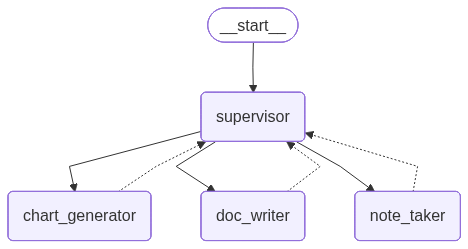

In [100]:
paper_writing_builder = StateGraph(State)


paper_writing_builder.add_node("supervisor", doc_writing_supervisor_node)
paper_writing_builder.add_node("doc_writer", doc_writing_node)
paper_writing_builder.add_node("note_taker", note_taking_node)
paper_writing_builder.add_node("chart_generator", chart_generating_node)


paper_writing_builder.add_edge(START, "supervisor")
paper_writing_builder.add_edge("supervisor", "doc_writer")
paper_writing_builder.add_edge("supervisor", "note_taker")
paper_writing_builder.add_edge("supervisor", "chart_generator")
paper_writing_builder.add_edge("supervisor", END)

paper_writing_graph = paper_writing_builder.compile()
paper_writing_graph

In [91]:
from langchain_core.messages import BaseMessage
teams_supervisor_node = make_supervisor_node(llm, ["research_team", "writing_team"])
teams_supervisor_node

<function __main__.make_supervisor_node.<locals>.supervisor_node(state: __main__.State) -> langgraph.types.Command>

In [95]:
def call_research_team(state : State) -> Command[Literal["supervisor"]] :
    response = research_graph.invoke({"messages" : state["messages"][-1]}) # It's calling the Graph
    return Command(
        update = {"messages" : [HumanMessage(content = response["messages"][-1].content, name = "research_team")]}, goto = "supervisor" # Top supervisor
    )

def call_paper_writing_team(state : State) -> Command[Literal["supervisor"]] :
    response = paper_writing_graph.invoke({"messages" : state["messages"][-1]})

    return Command(
        update = {"messages" : [HumanMessage(content = response["messages"][-1].content, name = "writing_team")]}, goto= "supervisor"
    )


### Final Graph 

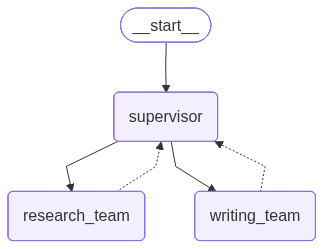

In [98]:
super_builder = StateGraph(State)
super_builder.add_node("supervisor", teams_supervisor_node)
super_builder.add_node("research_team", call_research_team)
super_builder.add_node("writing_team", call_paper_writing_team)

super_builder.add_edge(START, "supervisor")
super_builder.add_edge("supervisor", "research_team")
super_builder.add_edge("supervisor", "writing_team")
super_builder.add_edge("supervisor", END)
super_graph = super_builder.compile()
super_graph

In [ ]:
response = super_graph.invoke(
    {"messages" : [("user", "Write about transformer variants in production deployments")]}
)